# Neural Network Solver: 2nd-Order PDE (Heat Equation)

Solves the 1D heat equation:

$$u_t = D \cdot u_{xx}, \quad x \in [-5, 5],\ t \in [0, 5]$$

Initial condition: $u(x, 0) = \cos(\pi x) + \sin(\pi x)$

True solution: $u(x, t) = (\cos \pi x + \sin \pi x)\, e^{-D\pi^2 t}$

Set `diffusivity=1/pi**2` to recover the notebook convention $u(x,t) = (\cos\pi x + \sin\pi x)e^{-t}$.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from nn_de_solver.model import MLP
from nn_de_solver.trainer import Trainer
from nn_de_solver.problems.pde2 import HeatEquationProblem

In [2]:
problem = HeatEquationProblem(x_lb=-1.0, x_ub=1.0, t_ub=3.0, diffusivity=1/np.pi**2)
net = MLP(input_dim=2, hidden=(256, 256, 256, 256), activation='tanh')
trainer = Trainer(net, problem, lr=1e-3, use_lr_decay=True)

In [3]:
history = trainer.train(steps=40_000, batch_size=200, tol=5e-4, log_every=2_000)

step   2000 | mean loss: 0.8102 | 20.3s
step   4000 | mean loss: 0.2171 | 37.6s
step   6000 | mean loss: 0.1482 | 54.8s
step   8000 | mean loss: 0.1151 | 71.9s
step  10000 | mean loss: 0.0823 | 88.3s
step  12000 | mean loss: 0.0634 | 105.1s
step  14000 | mean loss: 0.0461 | 121.6s
step  16000 | mean loss: 0.0371 | 138.1s
step  18000 | mean loss: 0.0265 | 154.6s
step  20000 | mean loss: 0.0202 | 171.2s
step  22000 | mean loss: 0.0159 | 187.7s
step  24000 | mean loss: 0.0109 | 204.8s
step  26000 | mean loss: 0.0093 | 221.8s
step  28000 | mean loss: 0.0058 | 238.8s
step  30000 | mean loss: 0.0055 | 255.8s
step  32000 | mean loss: 0.0038 | 272.7s
step  34000 | mean loss: 0.0028 | 289.5s
step  36000 | mean loss: 0.0025 | 305.9s
step  38000 | mean loss: 0.0022 | 322.2s
step  40000 | mean loss: 0.0021 | 338.5s


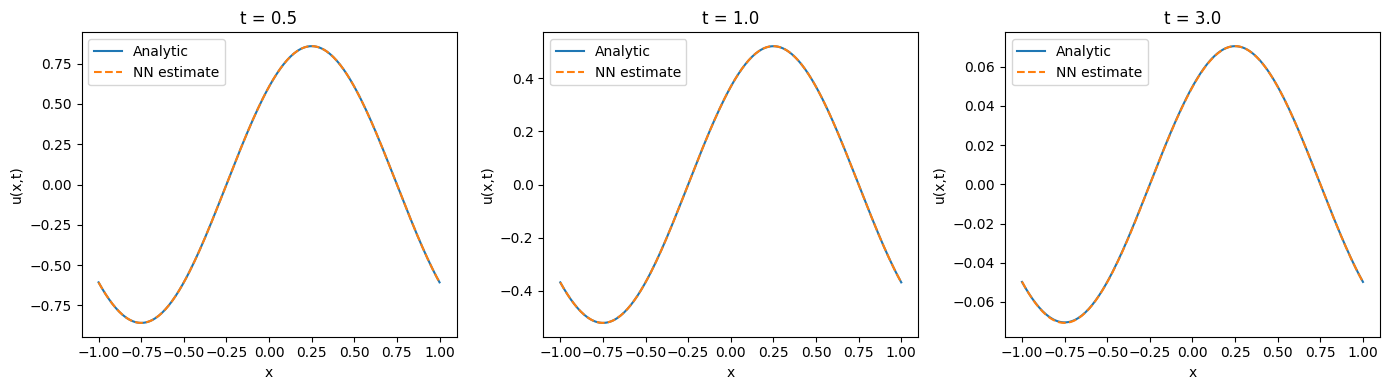

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
x_plot = np.linspace(-1, 1, 200).astype("float32")

for ax, t_val in zip(axes, [0.5, 1.0, 3.0]):
    t_arr = np.full_like(x_plot, t_val)
    xt = tf.constant(np.stack([x_plot, t_arr], axis=1))
    u_pred = net(xt).numpy().flatten()
    u_true = problem.true_solution(x_plot, t_val)
    ax.plot(x_plot, u_true, label="Analytic")
    ax.plot(x_plot, u_pred, "--", label="NN estimate")
    ax.set_title(f"t = {t_val}")
    ax.set_xlabel("x"); ax.set_ylabel("u(x,t)")
    ax.legend()

plt.tight_layout(); plt.show()

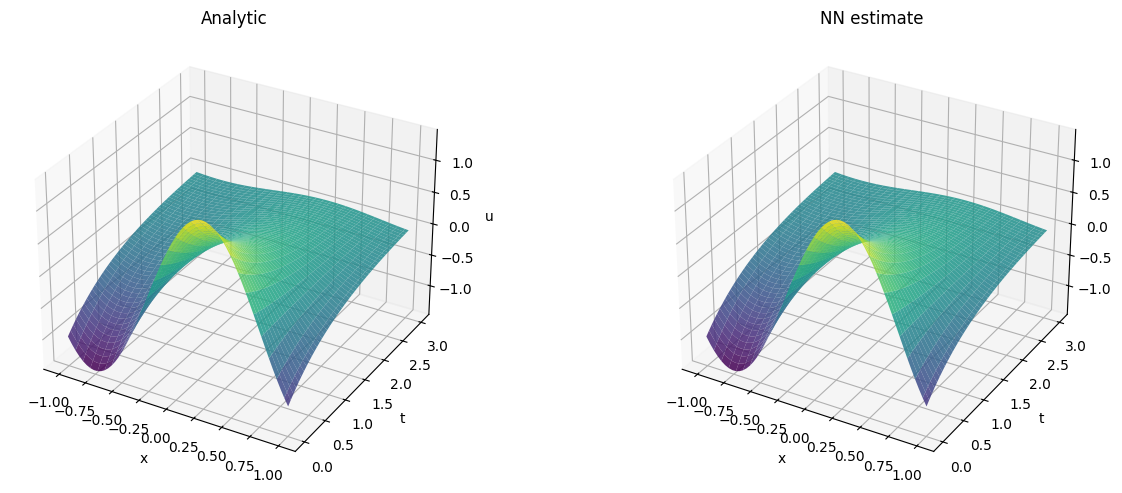

In [5]:
from matplotlib import cm

X = np.linspace(-1, 1, 60).astype("float32")
T = np.linspace(0, 3, 50).astype("float32")
XX, TT = np.meshgrid(X, T)
xt_grid = tf.constant(np.stack([XX.flatten(), TT.flatten()], axis=1))
UU_pred = net(xt_grid).numpy().reshape(XX.shape)
UU_true = problem.true_solution(XX, TT)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), subplot_kw={"projection": "3d"})
for ax, U, title in zip([ax1, ax2], [UU_true, UU_pred], ["Analytic", "NN estimate"]):
    ax.plot_surface(XX, TT, U, cmap=cm.viridis, alpha=0.85)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_zlabel("u")
    ax.set_title(title)

plt.tight_layout(); plt.show()